In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('C:/Users/LSG/Desktop/AICE/DAY15/customer_churn_risk_multiclass(2).csv')
df.head()

,customer_id,signup_date,age,monthly_usage_hours,support_tickets,satisfaction_score,monthly_fee,contract_type,payment_method,region,auto_renew,churn_risk
0,CUS-0146,2022-05-14,37,47.1,0,3.5,72.6,two_year,card,daegu,0,low
1,CUS-0281,2023-01-06,51,55.6,1,2.6,57.0,annual,card,busan,1,low
2,CUS-0176,2025-08-07,36,54.8,1,4.1,76.3,monthly,card,seoul,0,low
3,CUS-0411,2023-05-29,62,46.7,3,4.3,108.9,monthly,bank_transfer,daegu,1,medium
4,CUS-0420,2022-03-01,33,27.5,1,3.3,32.0,two_year,mobile,seoul,1,low


In [2]:
answer01 = df.shape
answer01

(423, 12)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 423 entries, 0 to 422
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          423 non-null    str    
 1   signup_date          423 non-null    str    
 2   age                  423 non-null    int64  
 3   monthly_usage_hours  413 non-null    float64
 4   support_tickets      423 non-null    int64  
 5   satisfaction_score   409 non-null    float64
 6   monthly_fee          423 non-null    float64
 7   contract_type        423 non-null    str    
 8   payment_method       415 non-null    str    
 9   region               423 non-null    str    
 10  auto_renew           423 non-null    int64  
 11  churn_risk           423 non-null    str    
dtypes: float64(3), int64(3), str(6)
memory usage: 39.8 KB


In [4]:
df.dtypes

customer_id                str
signup_date                str
age                      int64
monthly_usage_hours    float64
support_tickets          int64
satisfaction_score     float64
monthly_fee            float64
contract_type              str
payment_method             str
region                     str
auto_renew               int64
churn_risk                 str
dtype: object

In [5]:
df.describe()

,age,monthly_usage_hours,support_tickets,satisfaction_score,monthly_fee,auto_renew
count,423.000000,413.000000,423.000000,409.000000,423.000000,423.000000
mean,43.108747,38.184746,2.141844,3.493154,69.534279,0.479905
std,13.494338,13.194877,2.243204,0.861259,33.838619,0.500188
min,19.000000,2.000000,0.000000,1.000000,20.000000,0.000000
25%,31.000000,29.200000,1.000000,2.900000,54.850000,0.000000
50%,43.000000,38.300000,2.000000,3.500000,66.400000,0.000000
75%,55.000000,46.700000,3.000000,4.100000,79.900000,1.000000
max,65.000000,74.100000,20.000000,5.000000,358.500000,1.000000


In [6]:
answer02 = df.isnull().sum()
answer02

customer_id             0
signup_date             0
age                     0
monthly_usage_hours    10
support_tickets         0
satisfaction_score     14
monthly_fee             0
contract_type           0
payment_method          8
region                  0
auto_renew              0
churn_risk              0
dtype: int64

In [7]:
answer03 = df.duplicated().sum()
answer03

np.int64(3)

In [8]:
# 중복행 제거 누락
df = df.drop_duplicates().reset_index(drop=True)

In [9]:
risk_counts = df['churn_risk'].value_counts()
risk_counts

churn_risk
low       189
medium    168
high       63
Name: count, dtype: int64

In [10]:
# 비율 구하는거 기억하기
# 정리 필요
risk_ratio = df['churn_risk'].value_counts(normalize=True).round(2)
risk_ratio

churn_risk
low       0.45
medium    0.40
high      0.15
Name: proportion, dtype: float64

In [11]:
# 값 여러개 - 대괄호 한번 더 꼭 기억
contract_summary = df.groupby('contract_type')[['monthly_usage_hours','satisfaction_score','monthly_fee']].mean()
contract_summary

,monthly_usage_hours,satisfaction_score,monthly_fee
contract_type,,,
annual,38.892361,3.519718,67.709459
monthly,38.046766,3.479899,71.882524
two_year,37.584615,3.490769,66.834848


In [12]:
# idxmax - 가장 큰 값이 있는 인덱스 이름
# 정리 필요
answer04 = contract_summary['monthly_fee'].idxmax()
answer04

'monthly'

In [13]:
df_clean = df.copy()

In [14]:
df['signup_date'] = pd.to_datetime(df['signup_date'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   customer_id          420 non-null    str           
 1   signup_date          420 non-null    datetime64[us]
 2   age                  420 non-null    int64         
 3   monthly_usage_hours  410 non-null    float64       
 4   support_tickets      420 non-null    int64         
 5   satisfaction_score   406 non-null    float64       
 6   monthly_fee          420 non-null    float64       
 7   contract_type        420 non-null    str           
 8   payment_method       412 non-null    str           
 9   region               420 non-null    str           
 10  auto_renew           420 non-null    int64         
 11  churn_risk           420 non-null    str           
dtypes: datetime64[us](1), float64(3), int64(3), str(5)
memory usage: 39.5 KB


In [15]:
# df['membership_days'] = (pd.to_datetime('2026-07-31') -  df['signup_date']).dt.days
# 복습 필요
reference_date = pd.Timestamp('2026-07-31')
df['membership_date'] = (reference_date - df['signup_date']).dt.days 

In [16]:
df = df.drop(['customer_id','signup_date'], axis=1)
df.head()

,age,monthly_usage_hours,support_tickets,satisfaction_score,monthly_fee,contract_type,payment_method,region,auto_renew,churn_risk,membership_date
0,37,47.1,0,3.5,72.6,two_year,card,daegu,0,low,1539
1,51,55.6,1,2.6,57.0,annual,card,busan,1,low,1302
2,36,54.8,1,4.1,76.3,monthly,card,seoul,0,low,358
3,62,46.7,3,4.3,108.9,monthly,bank_transfer,daegu,1,medium,1159
4,33,27.5,1,3.3,32.0,two_year,mobile,seoul,1,low,1613


In [17]:
df['monthly_usage_hours'] = df['monthly_usage_hours'].fillna(df['monthly_usage_hours'].mean())
df['satisfaction_score'] = df['satisfaction_score'].fillna(df['satisfaction_score'].median())
df['payment_method'] = df['payment_method'].fillna(df['payment_method'].mode()[0])

# 모든 열의 결측치 총 합 어떻게 하는지 모름
answer07 = df.isnull().sum().sum()
answer07

np.int64(0)

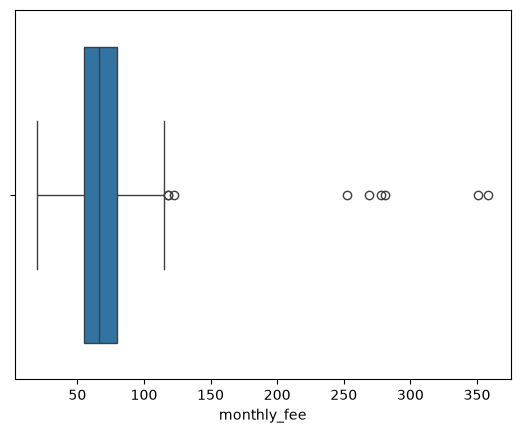

In [18]:
plt.figure()
sns.boxplot(data=df, x='monthly_fee')
plt.show()

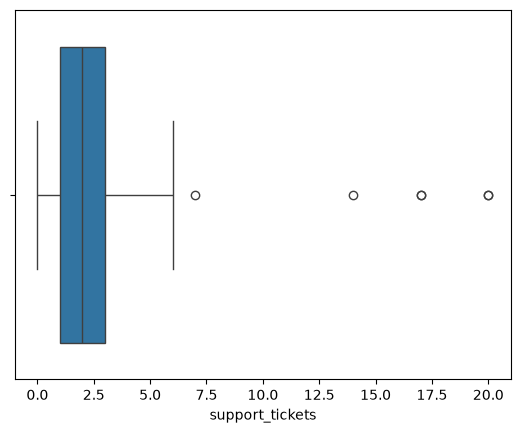

In [19]:
plt.figure()
sns.boxplot(data=df, x='support_tickets')
plt.show()

In [20]:
# 복습 필요
Q1 = df['monthly_fee'].quantile(0.25)
Q3 = df['monthly_fee'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [21]:
# loc 혹은 clip으로 가능. 하한값 보다 작으면 하한값, 상한값보다 크면 상한값
# 정리 필요
df['monthly_fee'] = df['monthly_fee'].clip(
    lower=lower_bound,
    upper=upper_bound
)

In [22]:
answer08 = df['monthly_fee'].max()
answer08

np.float64(117.50000000000003)

In [23]:
# 라벨 인코더 복습 필요
from sklearn.preprocessing import LabelEncoder

contract_incoder = LabelEncoder()
target_incoder = LabelEncoder()

df = pd.get_dummies(df, columns=['payment_method', 'region'], dtype=int)

# 계약 유형 전용 인코더
df['contract_type'] = contract_incoder.fit_transform(df['contract_type'])

df['churn_risk'] = target_incoder.fit_transform(df['churn_risk'])

print(contract_incoder.classes_)
print(target_incoder.classes_)
print(df.dtypes)
print(df.head())


['annual' 'monthly' 'two_year']
['high' 'low' 'medium']
age                               int64
monthly_usage_hours             float64
support_tickets                   int64
satisfaction_score              float64
monthly_fee                     float64
contract_type                     int64
auto_renew                        int64
churn_risk                        int64
membership_date                   int64
payment_method_bank_transfer      int64
payment_method_card               int64
payment_method_cash               int64
payment_method_mobile             int64
region_busan                      int64
region_daegu                      int64
region_daejeon                    int64
region_gwangju                    int64
region_seoul                      int64
dtype: object
   age  monthly_usage_hours  support_tickets  satisfaction_score  monthly_fee  \
0   37                 47.1                0                 3.5         72.6   
1   51                 55.6                1    

In [24]:
from sklearn.model_selection import train_test_split

x = df.drop('churn_risk', axis=1)
y= df['churn_risk']

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    train_size=0.8,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(x_train, x_test, y_train, y_test)


     age  monthly_usage_hours  support_tickets  satisfaction_score  \
157   41                 33.7                1                 3.1   
72    65                 39.5                3                 3.1   
340   55                 31.6                7                 4.1   
377   62                 35.7                1                 3.7   
42    65                 12.5                0                 4.4   
..   ...                  ...              ...                 ...   
32    63                 42.7                3                 4.7   
348   42                 36.6                3                 2.9   
259   40                 35.5                2                 4.3   
247   44                 32.9                1                 3.5   
148   54                 27.8                1                 3.8   

     monthly_fee  contract_type  auto_renew  membership_date  \
157         69.5              2           0              359   
72          76.8              1

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [26]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

model_a = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    random_state=42
)

model_b = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42,
    class_weight='balanced'
)

model_a.fit(x_train, y_train)
model_b.fit(x_train, y_train)

pred_a = model_a.predict(x_test)
pred_b = model_b.predict(x_test)



In [27]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

# f1 계산 시 다중분류면 average='macro' 넣어줘야함

print('A')
print(accuracy_score(pred_a, y_test))
print(f1_score(pred_a, y_test, average='macro'))
print(classification_report(pred_a, y_test))
print('B')
print(accuracy_score(pred_b, y_test))
print(f1_score(pred_b, y_test, average='macro'))
print(classification_report(pred_b, y_test))

answer12 = 'RandomForest'
# 여기까지 풀고 시간 다됨 - 12번

A
0.5238095238095238
0.4480422023387555
              precision    recall  f1-score   support

           0       0.15      0.33      0.21         6
           1       0.53      0.69      0.60        29
           2       0.67      0.45      0.54        49

    accuracy                           0.52        84
   macro avg       0.45      0.49      0.45        84
weighted avg       0.58      0.52      0.53        84

B
0.6071428571428571
0.5171042760690173
              precision    recall  f1-score   support

           0       0.23      0.43      0.30         7
           1       0.87      0.69      0.77        48
           2       0.45      0.52      0.48        29

    accuracy                           0.61        84
   macro avg       0.52      0.54      0.52        84
weighted avg       0.67      0.61      0.63        84



In [28]:
# 정리 필요 
from tensorflow.keras.utils import to_categorical

num_classes = len(np.unique(y_train))

y_train_onehot = to_categorical(
    y_train,
    num_classes=num_classes
)

y_test_onehot = to_categorical(
    y_test,
    num_classes=num_classes
)

print(y_train.shape)
print(y_train_onehot.shape)

print(y_train[:5])
print(y_train_onehot[:5])

(336,)
(336, 3)
157    1
72     2
340    1
377    1
42     2
Name: churn_risk, dtype: int64
[[0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

# elu 설명 필요
# shape에 들어가는 값 꼭 기억하기 
model = Sequential([
    Input(shape=(x_train_scaled.shape[1],)),
    Dense(64, activation='elu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,331 (13.01 KB)

 Trainable params: 3,331 (13.01 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping

checkpoint = ModelCheckpoint(
    filepath='best_churn_model.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

print(x_train_scaled.shape)
print(model.input_shape)

(336, 17)
(None, 17)


In [31]:
history = model.fit(
    x_train_scaled,
    y_train_onehot,
    epochs=100,
    validation_split=0.2,
    batch_size=32,
    callbacks=[checkpoint,early_stop],
    verbose=1
)

Epoch 1/100
1/9 ━━━━━━━━━━━━━━━━━━━━ 6s 776ms/step - accuracy: 0.4375 - loss: 1.1233
Epoch 1: val_loss improved from None to 1.05512, saving model to best_churn_model.keras

Epoch 1: finished saving model to best_churn_model.keras
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.4142 - loss: 1.1584 - val_accuracy: 0.3824 - val_loss: 1.0551
Epoch 2/100
1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3125 - loss: 1.1565
Epoch 2: val_loss improved from 1.05512 to 0.98181, saving model to best_churn_model.keras

Epoch 2: finished saving model to best_churn_model.keras
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4403 - loss: 1.0470 - val_accuracy: 0.3824 - val_loss: 0.9818
Epoch 3/100
1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5625 - loss: 0.9788
Epoch 3: val_loss improved from 0.98181 to 0.93163, saving model to best_churn_model.keras

Epoch 3: finished saving model to best_churn_model.keras
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4739 - loss: 0.9924 - va

In [32]:
from tensorflow.keras.models import load_model

# 복습 필요
best_model = load_model('best_churn_model.keras')

best_loss, best_accuracy = best_model.evaluate(
    x_test_scaled,
    y_test_onehot
)

print(best_loss)
print(best_accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5833 - loss: 0.8531  
0.8530774712562561
0.5833333134651184


In [33]:
# 예측 확률을 클래스로 변환
# x_test_scaled의 클래스별 확률 예측
y_pred_proba = best_model.predict(x_test_scaled)

print(y_pred_proba.shape)
print(y_pred_proba[:5])

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
(84, 3)
[[0.15906203 0.32229903 0.51863897]
 [0.12323097 0.26747638 0.6092926 ]
 [0.01708099 0.8865241  0.09639493]
 [0.19184671 0.2621384  0.54601496]
 [0.1712711  0.27642354 0.55230534]]


In [34]:
y_pred_dl = np.argmax(y_pred_proba, axis=1)

print(y_pred_dl[:10])

[2 2 1 2 2 2 1 1 2 2]


In [35]:
# 혼동행렬, 평가보고서
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred_dl))
print(classification_report(y_test, y_pred_dl))

[[ 3  2  8]
 [ 0 28 10]
 [ 0 15 18]]
              precision    recall  f1-score   support

           0       1.00      0.23      0.38        13
           1       0.62      0.74      0.67        38
           2       0.50      0.55      0.52        33

    accuracy                           0.58        84
   macro avg       0.71      0.50      0.52        84
weighted avg       0.63      0.58      0.57        84



In [36]:
# 최고 정확도 
print("머신러닝 : ",accuracy_score(pred_b, y_test))
print("딥러닝 : ", best_accuracy)

머신러닝 :  0.6071428571428571
딥러닝 :  0.5833333134651184


In [ ]:
answer14 = 'Machine Learning'